In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026412.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000

In [2]:
# Install additional libraries if needed
!pip install timm
!pip install torchmetrics
!pip install grad-cam
!pip install umap-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=1746830b6112aeab282ccb2281c52ea17b9d8c5fc9f1f9669136b90a9763aac2
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

import timm
from torchmetrics.classification import MulticlassAccuracy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


2026-02-12 17:06:43.740550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770916003.932831      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770916003.987217      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770916004.445255      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770916004.445295      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770916004.445298      55 computation_placer.cc:177] computation placer alr

Device: cuda


In [4]:
import pandas as pd
import os

# Correct path to dataset
DATA_DIR = "/kaggle/input/skin-cancer-mnist-ham10000"

# Load metadata CSV
metadata = pd.read_csv(os.path.join(DATA_DIR, "HAM10000_metadata.csv"))

# Check if loaded properly
print(metadata.head())
print("Total samples:", len(metadata))


     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
Total samples: 10015


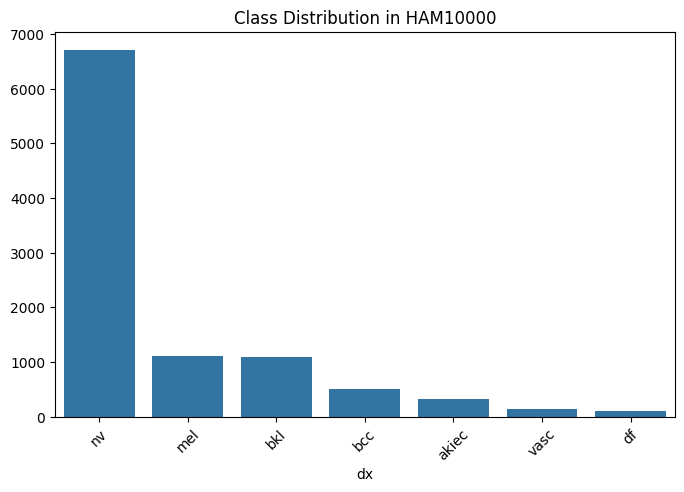

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing class distribution
class_counts = metadata['dx'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution in HAM10000")
plt.xticks(rotation=45)
plt.show()

print(class_counts)


In [6]:
import os

# Create dictionary of image_id → full path
image_paths = {}

for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    folder_path = os.path.join(DATA_DIR, folder)
    
    for img in os.listdir(folder_path):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder_path, img)

# Map full path to metadata
metadata["path"] = metadata["image_id"].map(image_paths)

print(metadata[["image_id", "dx", "path"]].head())


       image_id   dx                                               path
0  ISIC_0027419  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
1  ISIC_0025030  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
2  ISIC_0026769  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
3  ISIC_0025661  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4  ISIC_0031633  bkl  /kaggle/input/skin-cancer-mnist-ham10000/HAM10...


In [7]:
# Create label encoder
label_mapping = {label: idx for idx, label in enumerate(metadata["dx"].unique())}
metadata["label"] = metadata["dx"].map(label_mapping)

print(label_mapping)


{'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


In [8]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))


Train size: 8012
Val size: 2003


In [9]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=15, scale=(0.8,1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
#This improves minority class diversity.

In [10]:
from torch.utils.data import Dataset
from PIL import Image

class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["path"]
        label = self.df.iloc[idx]["label"]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


In [11]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# Count class frequency in train set
class_counts = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts

# Assign weight to each sample
sample_weights = train_df["label"].map(class_weights).values
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_dataset = HAMDataset(train_df, transform=train_transform)
val_dataset = HAMDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [12]:
import torchvision.models as models
import torch.nn as nn

model_resnet = models.resnet18(pretrained=True)

# Replace final layer
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.5),  # Regularization
    nn.Linear(model_resnet.fc.in_features, 7)
)

model_resnet = model_resnet.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


In [13]:
import timm

model_effnet = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=7
)

model_effnet = model_effnet.to(device)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [14]:
weights_tensor = torch.tensor(class_weights.values, dtype=torch.float).to(device)

criterion_weighted = nn.CrossEntropyLoss(weight=weights_tensor)


In [15]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')
        
    def forward(self, outputs, targets):
        ce_loss = self.ce(outputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


In [16]:
optimizer_resnet = torch.optim.AdamW(
    model_resnet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

optimizer_effnet = torch.optim.SGD(
    model_effnet.parameters(),
    lr=0.01,
    momentum=0.9
)


In [17]:
def train_model(model, optimizer, criterion, epochs=5):
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")


In [18]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score, f1_score

def evaluate(model):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    print(classification_report(all_labels, all_preds))
    
    print("Balanced Accuracy:",
          balanced_accuracy_score(all_labels, all_preds))
    
    print("Macro F1:",
          f1_score(all_labels, all_preds, average='macro'))
    
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()


In [19]:
from sklearn.manifold import TSNE

def visualize_tsne(model):
    model.eval()
    features = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            
            features.append(outputs.cpu().numpy())
            labels_list.extend(labels.numpy())
    
    features = np.vstack(features)
    
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(features)
    
    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1],
                c=labels_list, cmap='tab10')
    plt.title("t-SNE Feature Space")
    plt.show()


In [20]:
def error_analysis(model):
    model.eval()
    misclassified = []
    
    with torch.no_grad():
        for i, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            for j in range(len(preds)):
                if preds[j] != labels[j]:
                    misclassified.append((images[j].cpu(), preds[j].item(), labels[j].item()))
    
    print("Total Misclassified:", len(misclassified))
    return misclassified


In [32]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN, self).__init__()
        
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2,2)
        
        # -------- Block 1 --------
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        
        # -------- Block 2 --------
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        
        # -------- Block 3 --------
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)
        
        # -------- Block 4 --------
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(512)
        
        # Global Average Pooling (important improvement)
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        
        # Classifier
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)
        
    def forward(self, x):
        
        # Block 1
        x = self.relu(self.bn1_1(self.conv1_1(x)))
        x = self.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool(x)
        
        # Block 2
        x = self.relu(self.bn2_1(self.conv2_1(x)))
        x = self.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool(x)
        
        # Block 3
        x = self.relu(self.bn3_1(self.conv3_1(x)))
        x = self.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool(x)
        
        # Block 4
        x = self.relu(self.bn4_1(self.conv4_1(x)))
        x = self.relu(self.bn4_2(self.conv4_2(x)))
        x = self.pool(x)
        
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x


In [22]:
model_custom = CustomCNN().to(device)

total_params = sum(p.numel() for p in model_custom.parameters())
trainable_params = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)


Total Parameters: 26083591
Trainable Parameters: 26083591


In [23]:
# Instantiate models

model_custom = CustomCNN().to(device)

model_resnet = models.resnet18(pretrained=True)
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model_resnet.fc.in_features, 7)
)
model_resnet = model_resnet.to(device)

import timm
model_effnet = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=7
).to(device)


In [24]:
criterion_ce = nn.CrossEntropyLoss()


In [34]:
criterion_custom = FocalLoss(gamma=2)


In [35]:
optimizer_custom = torch.optim.AdamW(
    model_custom.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)


In [37]:
scheduler.step()


In [26]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, outputs, targets):
        ce_loss = self.ce(outputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion_focal = FocalLoss(gamma=2)


In [33]:
def train_model(model, optimizer, criterion, epochs=5):
    
    train_losses = []
    train_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        loop = tqdm(train_loader, leave=True)
        
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            loop.set_postfix(
                loss=loss.item(),
                acc=correct/total
            )
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        print(f"Train Loss: {epoch_loss:.4f}")
        print(f"Train Acc: {epoch_acc:.4f}")
    
    return train_losses, train_accuracies


In [38]:
# Reinitialize model
model_custom = CustomCNN().to(device)

# Loss
criterion_custom = FocalLoss(gamma=2)

# Optimizer
optimizer_custom = torch.optim.AdamW(
    model_custom.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Train
loss_custom, acc_custom = train_model(
    model_custom,
    optimizer_custom,
    criterion_custom,
    epochs=8
)



Epoch 1/8


100%|██████████| 251/251 [03:18<00:00,  1.26it/s, acc=0.338, loss=0.898]


Train Loss: 1.1715
Train Acc: 0.3376

Epoch 2/8


100%|██████████| 251/251 [03:17<00:00,  1.27it/s, acc=0.399, loss=1.46] 


Train Loss: 1.0514
Train Acc: 0.3990

Epoch 3/8


...

Train Loss: 0.8399
Train Acc: 0.4984

Epoch 7/8


100%|██████████| 251/251 [03:15<00:00,  1.29it/s, acc=0.504, loss=0.728]


Train Loss: 0.8226
Train Acc: 0.5037

Epoch 8/8


100%|██████████| 251/251 [03:13<00:00,  1.30it/s, acc=0.524, loss=0.937]

Train Loss: 0.7877
Train Acc: 0.5241


              precision    recall  f1-score   support

           0       0.30      0.37      0.33       220
           1       0.97      0.60      0.74      1341
           2       0.05      0.43      0.09        23
           3       0.32      0.56      0.41       223
           4       0.68      0.75      0.71        28
           5       0.22      0.24      0.23       103
           6       0.18      0.49      0.26        65

    accuracy                           0.55      2003
   macro avg       0.39      0.49      0.40      2003
weighted avg       0.75      0.55      0.61      2003

Balanced Accuracy: 0.49290262736447027
Macro F1: 0.3969597195435674


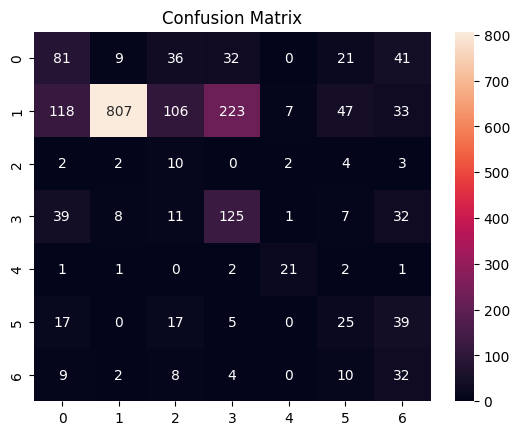

In [39]:
evaluate(model_custom)


In [25]:
weights_tensor = torch.tensor(class_weights.values, dtype=torch.float).to(device)
criterion_weighted = nn.CrossEntropyLoss(weight=weights_tensor)


In [36]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_custom,
    T_max=10
)


In [27]:
optimizer_custom = torch.optim.Adam(model_custom.parameters(), lr=1e-4)

optimizer_resnet = torch.optim.AdamW(model_resnet.parameters(), lr=1e-4)

optimizer_effnet = torch.optim.SGD(
    model_effnet.parameters(),
    lr=0.01,
    momentum=0.9
)


In [29]:
print("Training Custom CNN with Weighted CE")

loss_custom, acc_custom = train_model(
    model_custom,
    optimizer_custom,
    criterion_weighted,
    epochs=5
)


Training Custom CNN with Weighted CE

Epoch 1/5


100%|██████████| 251/251 [02:05<00:00,  2.00it/s, acc=0.281, loss=1.2]  


Epoch Time: 2.09 minutes

Epoch 2/5


100%|██████████| 251/251 [01:54<00:00,  2.20it/s, acc=0.335, loss=0.832]


Epoch Time: 4.00 minutes

Epoch 3/5


...

100%|██████████| 251/251 [01:51<00:00,  2.26it/s, acc=0.369, loss=0.75] 


Epoch Time: 7.74 minutes

Epoch 5/5


100%|██████████| 251/251 [01:48<00:00,  2.30it/s, acc=0.387, loss=0.816]

Epoch Time: 9.56 minutes

Total Training Time: 9.56 minutes


TypeError: cannot unpack non-iterable NoneType object

In [40]:
print("Training ResNet with Focal Loss")

loss_resnet, acc_resnet = train_model(
    model_resnet,
    optimizer_resnet,
    criterion_focal,
    epochs=5
)


Training ResNet with Focal Loss

Epoch 1/5


100%|██████████| 251/251 [01:49<00:00,  2.29it/s, acc=0.647, loss=0.496]


Train Loss: 0.5659
Train Acc: 0.6473

Epoch 2/5


100%|██████████| 251/251 [01:49<00:00,  2.30it/s, acc=0.768, loss=0.33]  


Train Loss: 0.3161
Train Acc: 0.7677

Epoch 3/5


...

Train Loss: 0.2363
Train Acc: 0.8112

Epoch 4/5


100%|██████████| 251/251 [01:47<00:00,  2.32it/s, acc=0.832, loss=0.205] 


Train Loss: 0.2059
Train Acc: 0.8315

Epoch 5/5


100%|██████████| 251/251 [01:48<00:00,  2.32it/s, acc=0.85, loss=0.161]  

Train Loss: 0.1830
Train Acc: 0.8499


ResNet Evaluation
              precision    recall  f1-score   support

           0       0.58      0.75      0.66       220
           1       0.95      0.83      0.89      1341
           2       0.87      0.57      0.68        23
           3       0.49      0.65      0.56       223
           4       0.76      0.89      0.82        28
           5       0.69      0.82      0.75       103
           6       0.56      0.68      0.62        65

    accuracy                           0.80      2003
   macro avg       0.70      0.74      0.71      2003
weighted avg       0.83      0.80      0.81      2003

Balanced Accuracy: 0.7416078027624974
Macro F1: 0.7103927526489969


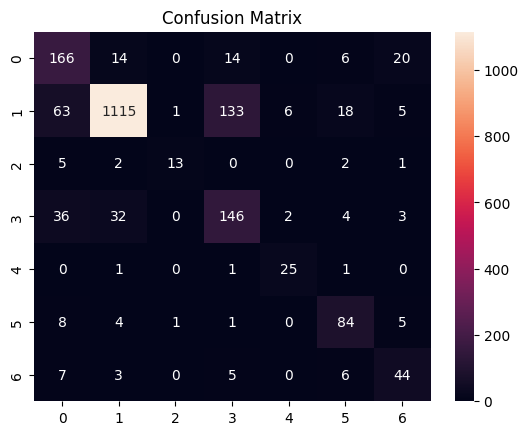

In [41]:
print("ResNet Evaluation")
evaluate(model_resnet)

In [42]:
print("Training EfficientNet with Normal CE")

loss_effnet, acc_effnet = train_model(
    model_effnet,
    optimizer_effnet,
    criterion_ce,
    epochs=5
)


Training EfficientNet with Normal CE

Epoch 1/5


100%|██████████| 251/251 [02:03<00:00,  2.03it/s, acc=0.575, loss=1.1]  


Train Loss: 1.2876
Train Acc: 0.5746

Epoch 2/5


100%|██████████| 251/251 [02:04<00:00,  2.02it/s, acc=0.755, loss=1.03] 


Train Loss: 0.6595
Train Acc: 0.7549

Epoch 3/5


...

Train Loss: 0.5152
Train Acc: 0.8078

Epoch 4/5


100%|██████████| 251/251 [02:04<00:00,  2.02it/s, acc=0.843, loss=0.317]


Train Loss: 0.4147
Train Acc: 0.8426

Epoch 5/5


100%|██████████| 251/251 [02:03<00:00,  2.03it/s, acc=0.871, loss=0.552] 

Train Loss: 0.3580
Train Acc: 0.8711


EfficientNet Evaluation
              precision    recall  f1-score   support

           0       0.52      0.68      0.59       220
           1       0.96      0.73      0.83      1341
           2       0.72      0.57      0.63        23
           3       0.44      0.74      0.55       223
           4       0.92      0.82      0.87        28
           5       0.58      0.86      0.69       103
           6       0.45      0.77      0.57        65

    accuracy                           0.74      2003
   macro avg       0.66      0.74      0.68      2003
weighted avg       0.81      0.74      0.76      2003

Balanced Accuracy: 0.7394497458221307
Macro F1: 0.6767954180179431


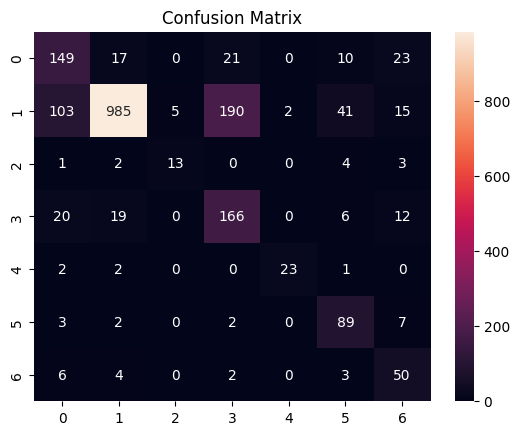

In [43]:

print("EfficientNet Evaluation")
evaluate(model_effnet)

In [ ]:
plt.plot(loss_custom, label="Custom")
plt.plot(loss_resnet, label="ResNet")
plt.plot(loss_effnet, label="EffNet")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()


In [ ]:
print("Custom CNN Evaluation")
evaluate(model_custom)

print("ResNet Evaluation")
evaluate(model_resnet)

print("EfficientNet Evaluation")
evaluate(model_effnet)


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("Custom CNN Params:", count_params(model_custom))
print("ResNet18 Params:", count_params(model_resnet))
print("EfficientNet Params:", count_params(model_effnet))


In [44]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

def compute_roc_auc(model):
    model.eval()
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    
    # Binarize labels
    y_bin = label_binarize(all_labels, classes=list(range(7)))
    
    roc_auc = roc_auc_score(y_bin, all_probs, average='macro')
    print("Macro ROC-AUC:", roc_auc)
    
    return all_labels, all_probs


In [45]:
labels_resnet, probs_resnet = compute_roc_auc(model_resnet)


Macro ROC-AUC: 0.9567387599518566


In [46]:
from sklearn.metrics import precision_recall_curve, auc

def compute_pr_auc(labels, probs):
    y_bin = label_binarize(labels, classes=list(range(7)))
    
    pr_aucs = []
    
    for i in range(7):
        precision, recall, _ = precision_recall_curve(
            y_bin[:, i], probs[:, i]
        )
        pr_auc = auc(recall, precision)
        pr_aucs.append(pr_auc)
    
    print("Macro PR-AUC:", np.mean(pr_aucs))


In [47]:
compute_pr_auc(labels_resnet, probs_resnet)


Macro PR-AUC: 0.7697611908106142


In [48]:
from sklearn.metrics import recall_score
import numpy as np

def compute_gmean(labels, preds):
    recalls = recall_score(labels, preds, average=None)
    gmean = np.prod(recalls) ** (1/len(recalls))
    print("G-Mean:", gmean)


In [49]:
# Get predictions
model_resnet.eval()
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_resnet(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())

compute_gmean(labels_resnet, all_preds)


G-Mean: 0.7336827998169727


In [50]:
!pip install ptflops


In [51]:
from ptflops import get_model_complexity_info

def compute_flops(model):
    with torch.cuda.device(0):
        macs, params = get_model_complexity_info(
            model,
            (3,224,224),
            as_strings=True,
            print_per_layer_stat=False
        )
    print("FLOPs:", macs)
    print("Parameters:", params)


In [52]:
compute_flops(model_custom)
compute_flops(model_resnet)
compute_flops(model_effnet)


FLOPs: 10.33 GMac
Parameters: 4.69 M
FLOPs: 1.82 GMac
Parameters: 11.18 M
FLOPs: 390.84 MMac
Parameters: 4.02 M


In [53]:
import time

def measure_inference_time(model):
    model.eval()
    dummy = torch.randn(1,3,224,224).to(device)
    
    start = time.time()
    
    for _ in range(100):
        _ = model(dummy)
    
    end = time.time()
    
    print("Avg Inference Time:",
          (end-start)/100, "seconds")


In [54]:
measure_inference_time(model_resnet)
measure_inference_time(model_effnet)
measure_inference_time(model_custom)


Avg Inference Time: 0.0030834031105041503 seconds
Avg Inference Time: 0.010441815853118897 seconds
Avg Inference Time: 0.004595942497253418 seconds


In [63]:
from sklearn.manifold import TSNE
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import numpy as np

def visualize_tsne(model, model_name, max_samples=1000):
    model.eval()
    features = []
    labels_list = []
    
    print(f"\nExtracting features for {model_name}...")
    
    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images = images.to(device)
            outputs = model(images)
            
            features.append(outputs.cpu().numpy())
            labels_list.extend(labels.numpy())
            
            # Optional: limit samples for faster t-SNE
            if len(labels_list) >= max_samples:
                break
    
    features = np.vstack(features)[:max_samples]
    labels_list = labels_list[:max_samples]
    
    print("Feature extraction time:",
          round((time.time() - start_time)/60, 2), "minutes")
    
    print(f"\nRunning t-SNE for {model_name}...")
    
    tsne_start = time.time()
    
    tsne = TSNE(
        n_components=2,
        random_state=42,
        verbose=1,       # shows iteration progress
        n_iter=1000      # default is 1000
    )
    
    reduced = tsne.fit_transform(features)
    
    print("t-SNE time:",
          round((time.time() - tsne_start)/60, 2), "minutes")
    
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        reduced[:,0],
        reduced[:,1],
        c=labels_list,
        cmap='tab10',
        s=10
    )
    plt.title(f"t-SNE Feature Space - {model_name}")
    plt.colorbar(scatter)
    plt.show()



Extracting features for Custom CNN...


 49%|████▉     | 31/63 [00:12<00:13,  2.41it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Feature extraction time: 0.21 minutes

Running t-SNE for Custom CNN...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.005s...
[t-SNE] Computed neighbors for 1000 samples in 0.021s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.872314
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.287369
[t-SNE] KL divergence after 1000 iterations: 0.695566
t-SNE time: 0.06 minutes


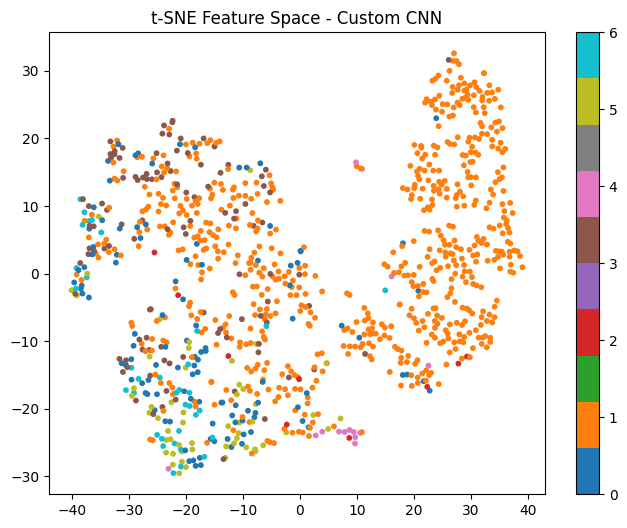


Extracting features for ResNet18...


 49%|████▉     | 31/63 [00:09<00:09,  3.21it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Feature extraction time: 0.16 minutes

Running t-SNE for ResNet18...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.002s...
[t-SNE] Computed neighbors for 1000 samples in 0.038s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 1.134944
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.670090
[t-SNE] KL divergence after 1000 iterations: 1.013089
t-SNE time: 0.07 minutes


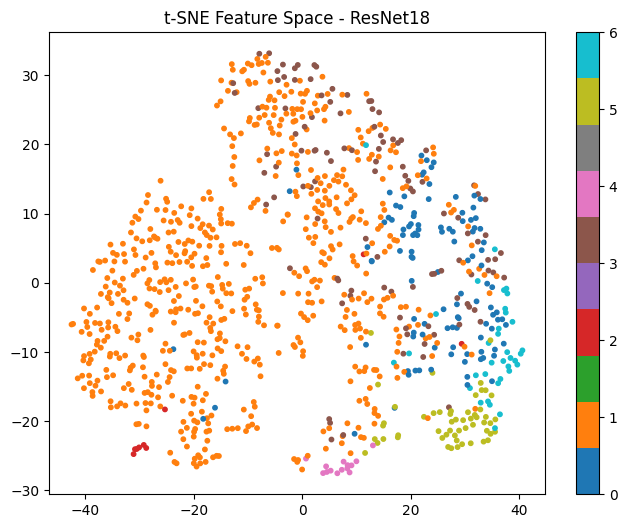


Extracting features for EfficientNet-B0...


 49%|████▉     | 31/63 [00:10<00:10,  3.07it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Feature extraction time: 0.17 minutes

Running t-SNE for EfficientNet-B0...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.001s...
[t-SNE] Computed neighbors for 1000 samples in 0.029s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 2.020127
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.081772
[t-SNE] KL divergence after 1000 iterations: 1.103897
t-SNE time: 0.06 minutes


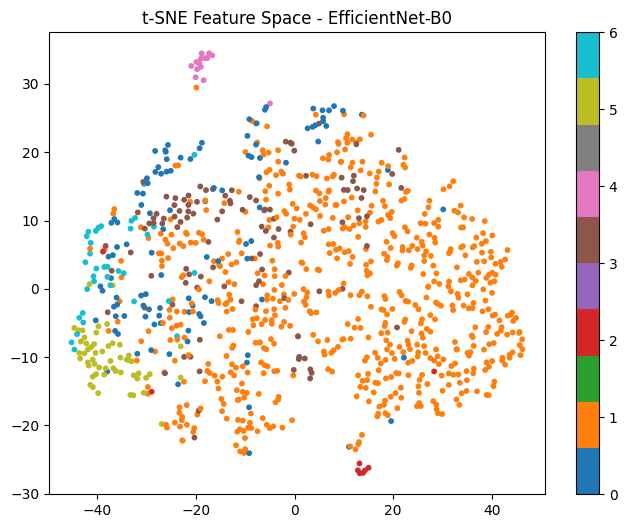

In [64]:
visualize_tsne(model_custom, "Custom CNN")
visualize_tsne(model_resnet, "ResNet18")
visualize_tsne(model_effnet, "EfficientNet-B0")


In [56]:
!pip install grad-cam


In [68]:
import time
import torch
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# -------- Helper: Find Last Conv Layer Automatically --------
def find_last_conv_layer(model):
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
    return last_conv

# -------- Universal Grad-CAM --------
def run_gradcam_universal(model, image_tensor, model_name="Model"):
    
    model.eval()
    image_tensor = image_tensor.to(device)
    
    start_time = time.time()
    
    # Forward pass to get prediction
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0))
        pred_class = torch.argmax(output, dim=1).item()
    
    # Automatically find last conv layer
    target_layer = find_last_conv_layer(model)
    
    cam = GradCAM(model=model,
                  target_layers=[target_layer])
    
    targets = [ClassifierOutputTarget(pred_class)]
    
    grayscale_cam = cam(
        input_tensor=image_tensor.unsqueeze(0),
        targets=targets
    )[0]
    
    # Normalize original image
    image_np = image_tensor.permute(1,2,0).cpu().numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    
    visualization = show_cam_on_image(
        image_np,
        grayscale_cam,
        use_rgb=True
    )
    
    end_time = time.time()
    
    print(f"Model: {model_name}")
    print(f"Predicted Class: {pred_class}")
    print(f"Grad-CAM Time: {round(end_time - start_time, 3)} seconds")
    
    plt.figure(figsize=(5,5))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM - {model_name}")
    plt.axis("off")
    plt.show()


Model: ResNet18
Predicted Class: 1
Grad-CAM Time: 0.021 seconds


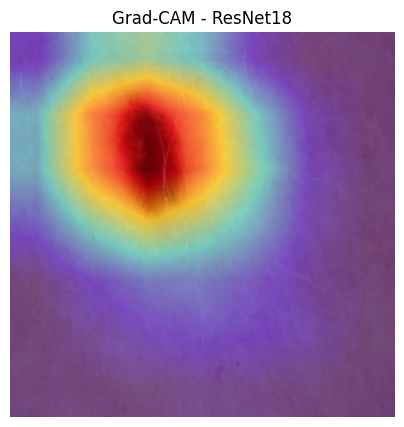

Model: EfficientNet
Predicted Class: 1
Grad-CAM Time: 0.064 seconds


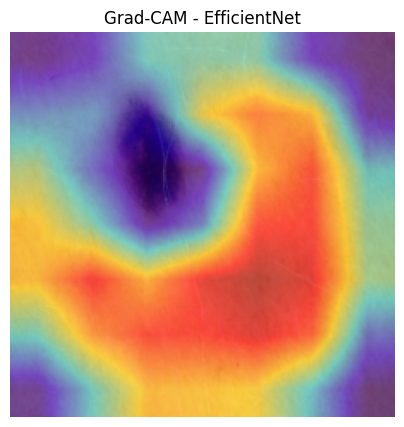

Model: Custom CNN
Predicted Class: 1
Grad-CAM Time: 0.038 seconds


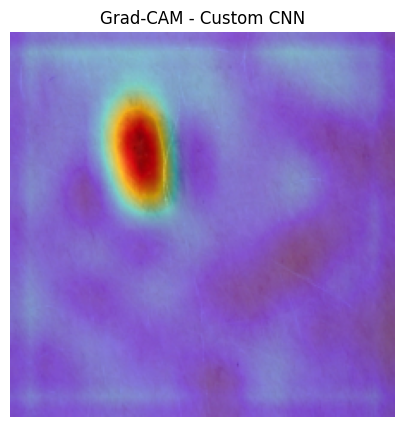

In [69]:
images, labels = next(iter(val_loader))
image_sample = images[0]

run_gradcam_universal(model_resnet, image_sample, "ResNet18")
run_gradcam_universal(model_effnet, image_sample, "EfficientNet")
run_gradcam_universal(model_custom, image_sample, "Custom CNN")



Training with CE


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/3


100%|██████████| 251/251 [01:47<00:00,  2.33it/s, acc=0.704, loss=0.756]


Train Loss: 0.8134
Train Acc: 0.7043

Epoch 2/3


100%|██████████| 251/251 [01:48<00:00,  2.32it/s, acc=0.818, loss=0.326]


Train Loss: 0.4883
Train Acc: 0.8184

Epoch 3/3


100%|██████████| 251/251 [01:48<00:00,  2.31it/s, acc=0.853, loss=0.852]


Train Loss: 0.3968
Train Acc: 0.8530
Evaluation:
              precision    recall  f1-score   support

           0       0.56      0.61      0.58       220
           1       0.96      0.83      0.89      1341
           2       0.59      0.57      0.58        23
           3       0.56      0.60      0.58       223
           4       0.60      0.93      0.73        28
           5       0.58      0.79      0.67       103
           6       0.36      0.83      0.50        65

    accuracy                           0.78      2003
   macro avg       0.60      0.74      0.65      2003
weighted avg       0.82      0.78      0.79      2003

Balanced Accuracy: 0.7357393531701295
Macro F1: 0.6470360062453574


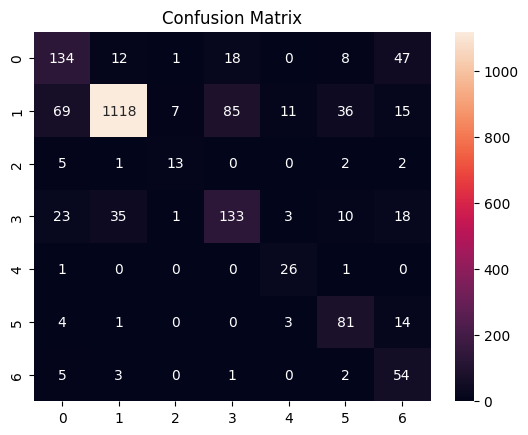

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training with WeightedCE

Epoch 1/3


100%|██████████| 251/251 [01:48<00:00,  2.32it/s, acc=0.574, loss=0.47] 


Train Loss: 0.4703
Train Acc: 0.5735

Epoch 2/3


100%|██████████| 251/251 [01:47<00:00,  2.33it/s, acc=0.741, loss=0.137] 


Train Loss: 0.2290
Train Acc: 0.7408

Epoch 3/3


100%|██████████| 251/251 [01:47<00:00,  2.33it/s, acc=0.794, loss=0.24]  


Train Loss: 0.1587
Train Acc: 0.7941
Evaluation:
              precision    recall  f1-score   support

           0       0.44      0.68      0.53       220
           1       1.00      0.46      0.63      1341
           2       0.18      0.70      0.29        23
           3       0.27      0.67      0.38       223
           4       0.42      0.96      0.59        28
           5       0.54      0.84      0.66       103
           6       0.27      0.72      0.40        65

    accuracy                           0.55      2003
   macro avg       0.45      0.72      0.50      2003
weighted avg       0.79      0.55      0.58      2003

Balanced Accuracy: 0.7202125118176363
Macro F1: 0.49779976295064887


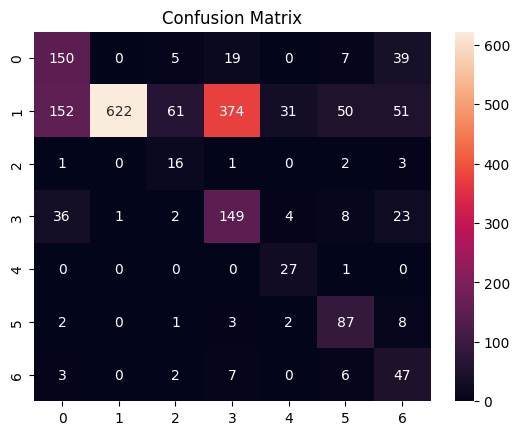

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training with Focal_gamma1

Epoch 1/3


100%|██████████| 251/251 [01:47<00:00,  2.33it/s, acc=0.694, loss=0.715]


Train Loss: 0.6093
Train Acc: 0.6941

Epoch 2/3


100%|██████████| 251/251 [01:47<00:00,  2.34it/s, acc=0.813, loss=0.431]


Train Loss: 0.3432
Train Acc: 0.8127

Epoch 3/3


100%|██████████| 251/251 [01:47<00:00,  2.33it/s, acc=0.851, loss=0.319] 


Train Loss: 0.2610
Train Acc: 0.8512
Evaluation:
              precision    recall  f1-score   support

           0       0.63      0.65      0.64       220
           1       0.94      0.81      0.87      1341
           2       0.71      0.52      0.60        23
           3       0.40      0.77      0.53       223
           4       0.92      0.86      0.89        28
           5       0.80      0.80      0.80       103
           6       0.70      0.54      0.61        65

    accuracy                           0.78      2003
   macro avg       0.73      0.71      0.71      2003
weighted avg       0.83      0.78      0.79      2003

Balanced Accuracy: 0.7062552837145076
Macro F1: 0.7051140194873816


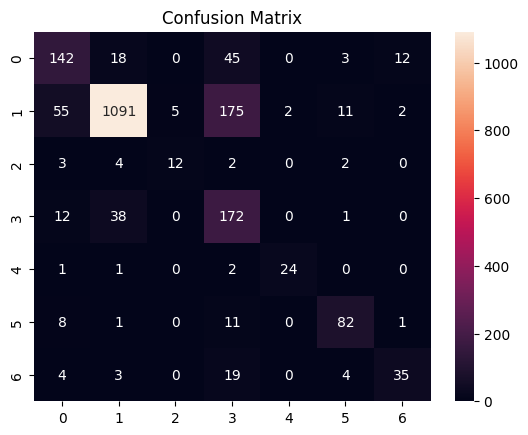

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training with Focal_gamma2

Epoch 1/3


100%|██████████| 251/251 [01:48<00:00,  2.31it/s, acc=0.691, loss=0.542]


Train Loss: 0.4737
Train Acc: 0.6915

Epoch 2/3


100%|██████████| 251/251 [01:48<00:00,  2.32it/s, acc=0.802, loss=0.31]  


Train Loss: 0.2531
Train Acc: 0.8017

Epoch 3/3


100%|██████████| 251/251 [01:48<00:00,  2.31it/s, acc=0.848, loss=0.196] 


Train Loss: 0.1890
Train Acc: 0.8484
Evaluation:
              precision    recall  f1-score   support

           0       0.47      0.79      0.59       220
           1       0.96      0.78      0.86      1341
           2       0.71      0.52      0.60        23
           3       0.46      0.45      0.46       223
           4       0.77      0.82      0.79        28
           5       0.57      0.80      0.66       103
           6       0.37      0.72      0.49        65

    accuracy                           0.74      2003
   macro avg       0.61      0.70      0.64      2003
weighted avg       0.80      0.74      0.76      2003

Balanced Accuracy: 0.6978053324611564
Macro F1: 0.6356124908137215


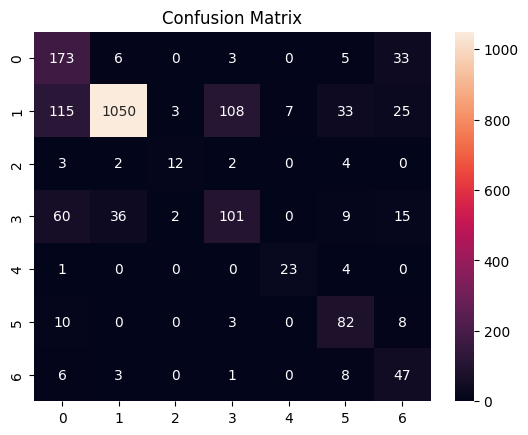

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training with Focal_gamma5

Epoch 1/3


100%|██████████| 251/251 [01:47<00:00,  2.34it/s, acc=0.682, loss=0.44]  


Train Loss: 0.2504
Train Acc: 0.6822

Epoch 2/3


100%|██████████| 251/251 [01:48<00:00,  2.32it/s, acc=0.797, loss=0.471] 


Train Loss: 0.1117
Train Acc: 0.7972

Epoch 3/3


100%|██████████| 251/251 [01:47<00:00,  2.33it/s, acc=0.822, loss=0.104] 


Train Loss: 0.0923
Train Acc: 0.8218
Evaluation:
              precision    recall  f1-score   support

           0       0.60      0.72      0.66       220
           1       0.95      0.76      0.84      1341
           2       0.35      0.52      0.42        23
           3       0.37      0.61      0.46       223
           4       0.87      0.93      0.90        28
           5       0.61      0.75      0.67       103
           6       0.43      0.72      0.54        65

    accuracy                           0.73      2003
   macro avg       0.60      0.72      0.64      2003
weighted avg       0.80      0.73      0.76      2003

Balanced Accuracy: 0.7156721666394353
Macro F1: 0.6404535300286851


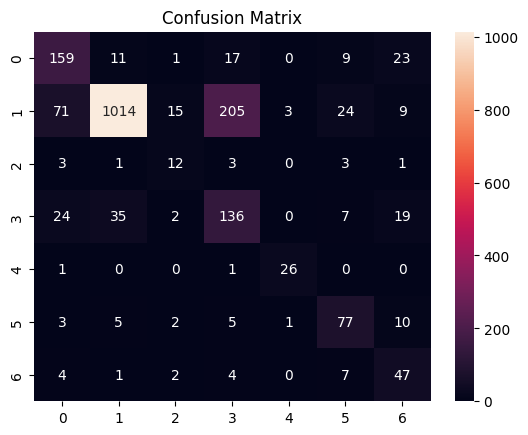

In [58]:
losses_to_test = {
    "CE": nn.CrossEntropyLoss(),
    "WeightedCE": nn.CrossEntropyLoss(weight=weights_tensor),
    "Focal_gamma1": FocalLoss(gamma=1),
    "Focal_gamma2": FocalLoss(gamma=2),
    "Focal_gamma5": FocalLoss(gamma=5)
}

for name, criterion in losses_to_test.items():
    print(f"\nTraining with {name}")
    
    model_temp = models.resnet18(pretrained=True)
    model_temp.fc = nn.Linear(model_temp.fc.in_features, 7)
    model_temp = model_temp.to(device)
    
    optimizer_temp = torch.optim.AdamW(
        model_temp.parameters(), lr=1e-4
    )
    
    train_model(model_temp, optimizer_temp, criterion, epochs=3)
    
    print("Evaluation:")
    evaluate(model_temp)


In [ ]:
criterion_ls = nn.CrossEntropyLoss(
    weight=weights_tensor,
    label_smoothing=0.1
)


In [ ]:
class ClassBalancedLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999):
        super().__init__()
        
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / effective_num
        weights = weights / np.sum(weights) * len(samples_per_class)
        
        self.weights = torch.tensor(weights, dtype=torch.float).to(device)
        self.ce = nn.CrossEntropyLoss(weight=self.weights)
    
    def forward(self, outputs, targets):
        return self.ce(outputs, targets)

samples_per_class = class_counts.values
criterion_cb = ClassBalancedLoss(samples_per_class)


In [ ]:
import matplotlib.pyplot as plt

def show_misclassified(model, num_images=6):
    
    model.eval()
    shown = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            for i in range(len(images)):
                if preds[i] != labels[i]:
                    
                    img = images[i].cpu().permute(1,2,0).numpy()
                    img = (img - img.min())/(img.max()-img.min())
                    
                    plt.imshow(img)
                    plt.title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
                    plt.axis("off")
                    plt.show()
                    
                    shown += 1
                    if shown >= num_images:
                        return


In [ ]:
show_misclassified(model_resnet)


In [ ]:
import torchvision.datasets as datasets

cifar = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=val_transform
)

cifar_loader = torch.utils.data.DataLoader(cifar, batch_size=32)

model_resnet.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in cifar_loader:
        images = images.to(device)
        outputs = model_resnet(images)
        preds = torch.argmax(outputs, dim=1)
        
        correct += (preds.cpu() == labels).sum().item()
        total += labels.size(0)

print("Transfer Accuracy on CIFAR10:", correct/total)
